In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt 
import pickle
from dep.automated_roi import ImageROIProcessor

In [2]:
def im_to_rgbim(im):

    rgba_image = np.zeros((im.shape[0], im.shape[1], 4), dtype=np.float64)
    rgba_image[..., 0] = im/np.max(im)  # Red channel
    rgba_image[..., 1] = im/np.max(im)  # Green channel
    rgba_image[..., 2] = im/np.max(im)  # Blue channel
    rgba_image[..., 3] = 1
    rgba_image = (rgba_image * 255).astype(np.uint8)
    return rgba_image


def rgba_to_dpgtex(rgba_image,gs_im_max,tex_name):
    w = 500#int((dpg.get_viewport_width()-left_indent-dpg.get_item_width('PTU_DATA_window')-5*internal_indent-init_widths['FCS_window']*ratio_w)//2)
    h = w
    # gba_image.shape)
    rgba_image  =cv2.resize(rgba_image, (w, h), interpolation=cv2.INTER_CUBIC)
    # rgba_image=rgba_image.astype(np.float32) /gs_im_max#np.max(rgba_image)#255
    
    new_texture_data = rgba_image.flatten().tolist()
    return rgba_image

In [3]:
# ls samples/new
path = 'samples/new/cell-201-01344.pkl'
ni = 'res/NO_image_INT.npy'

In [4]:
with open(path, 'rb') as pcklf:
    pklf = pickle.load(pcklf)


In [5]:
# pkl

Intensity_1 = pklf['intensity_1']
Intensity_2 = np.load(ni)
processor_1 = ImageROIProcessor()
processor_1.image=Intensity_1
processor_2 = ImageROIProcessor()
processor_2.image=Intensity_2

In [17]:
processor_1.image.dtype

dtype('uint64')

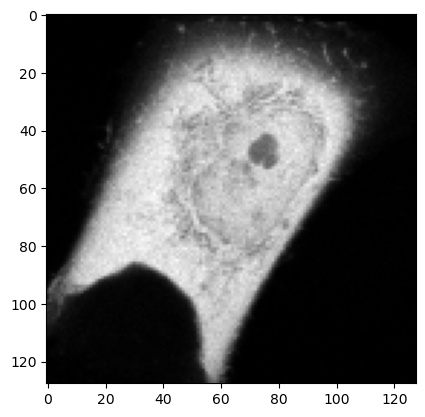

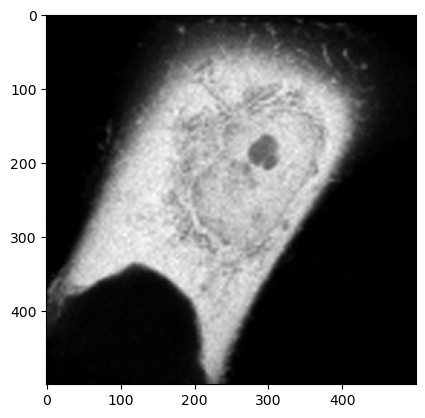

In [6]:
contrast = 1.
brightness = 0.
ovrl = 33
img = processor_1.image#.astype(np.uint8)
disp = processor_1.image#.astype(np.uint8)


rgba_image = im_to_rgbim(disp)
            
rgb = rgba_image[..., :3]
adjusted_image = rgb * contrast + brightness
adjusted_rgb = np.clip(adjusted_image, 0, 255)#.astype(np.uint8)
rgba_image[..., :3] = adjusted_rgb

im1=rgba_image

im1 = rgba_to_dpgtex(rgba_image,np.max(img),None)




plt.imshow(Intensity_1,cmap='gray')
plt.show()
plt.imshow(im1)


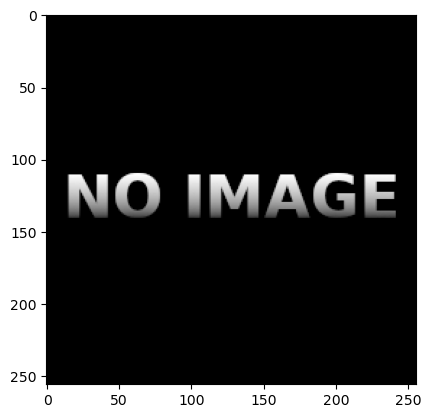

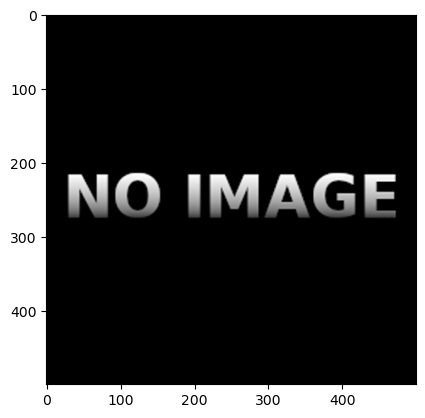

In [7]:
contrast = 1.
brightness = 0.
ovrl = 33
img = processor_2.image#.astype(np.uint8)
disp = processor_2.image#.astype(np.uint8)


rgba_image_1 = im_to_rgbim(processor_2.image)
            
# rgb = rgba_image[..., :3]
# adjusted_image = rgb * contrast + brightness
# adjusted_rgb = np.clip(adjusted_image, 0, 255)#.astype(np.uint8)
# rgba_image[..., :3] = adjusted_rgb
rgba_image_1  =cv2.resize(rgba_image_1, (500, 500), interpolation=cv2.INTER_CUBIC)
im2=rgba_image_1

# im2 = rgba_to_dpgtex(rgba_image,np.max(img),None)




plt.imshow(Intensity_2,cmap='gray')
plt.show()
plt.imshow(im2)

In [11]:
processor_2.image

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

(500, 500, 4)


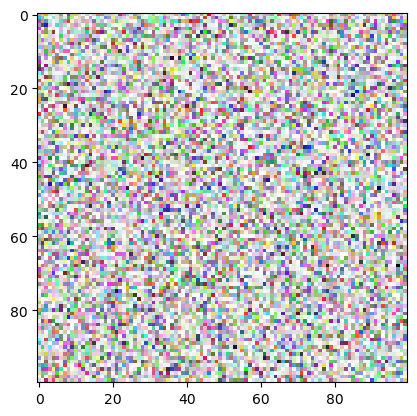

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..326].


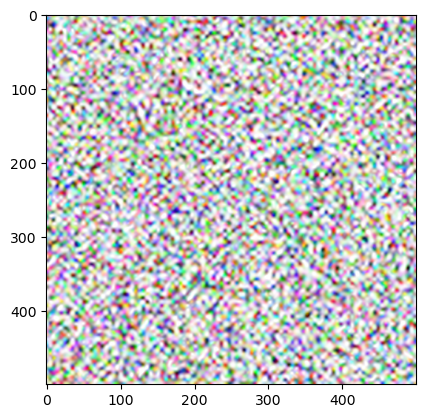

In [14]:
from scipy.ndimage import zoom

# Example of a numpy array with uint64 type
rgba_image = np.random.randint(0, 256, size=(100, 100, 4), dtype=np.uint64)

# Desired width and height
w, h = 500, 500

# Scale factors for resizing
zoom_factors = (h / rgba_image.shape[0], w / rgba_image.shape[1], 1)

# Resize the image using cubic interpolation
resized_image = zoom(rgba_image, zoom_factors, order=3)  # order=3 for cubic interpolation

print(resized_image.shape)
plt.imshow(rgba_image)
plt.show()
plt.imshow(resized_image)